## config

In [125]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA

import json
import glob

from googleapiclient.discovery import build

In [126]:
df = pd.read_json("../../data/processed/ve_channels/ve_with_features.json")
display(df.head())
display(df.info())

,channel_id,channel_name,title,description,country,topics,keywords,uploads,videos
0,UCqgh7QNlVV8kv3LBTJZYWrg,The Film Essay,The Film Essay,A video essay channel devoted to making videos...,GB,[https://en.wikipedia.org/wiki/Television_prog...,"""film essay"" ""video essay"" ""film analysis"" ""fi...",UUqgh7QNlVV8kv3LBTJZYWrg,[{'title': 'Why Christopher Nolan uses time as...
1,UCjFqcJQXGZ6T6sxyFB-5i6A,Every Frame a Painting,Every Frame a Painting,Taylor & Tony are gone again! Thanks for watch...,None,[https://en.wikipedia.org/wiki/Lifestyle_(soci...,"filmmaking ""film analysis"" ""video essay""",UUjFqcJQXGZ6T6sxyFB-5i6A,[{'title': 'Every Frame x Lackadaisy - Intervi...
2,UCr8r7UVsDaRiIQSVUHVBd_A,Nikki Carreon,Nikki Carreon,"Hello!! Just here making silly stuff, making s...",US,[https://en.wikipedia.org/wiki/Lifestyle_(soci...,None,UUr8r7UVsDaRiIQSVUHVBd_A,"[{'title': 'Why I Went to a MENTAL HOSPITAL.',..."
3,UCjKSoJlPgcK6BmoSqXpj5xQ,Action Button,Action Button,patreon.com/actionbutton\ntwitch.tv/actionbutt...,None,[https://en.wikipedia.org/wiki/Role-playing_vi...,None,UUjKSoJlPgcK6BmoSqXpj5xQ,"[{'title': 'ACTION BUTTON PICTURES PRESENTS ""L..."
4,UCUyvQV2JsICeLZP4c_h40kA,Thomas Flight,Thomas Flight,"Exploring the artistry behind cinema, TV, and ...",None,"[https://en.wikipedia.org/wiki/Entertainment, ...","movies film ""video essays"" ""film essay""",UUUyvQV2JsICeLZP4c_h40kA,"[{'title': 'Why Some Movies Feel More Alive', ..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   channel_id    251 non-null    object
 1   channel_name  251 non-null    object
 2   title         251 non-null    object
 3   description   251 non-null    object
 4   country       198 non-null    object
 5   topics        247 non-null    object
 6   keywords      159 non-null    object
 7   uploads       251 non-null    object
 8   videos        251 non-null    object
dtypes: object(9)
memory usage: 17.8+ KB


None

## cleaning

In [127]:
df = df.drop(["title", "uploads"], axis=1)
df = df.reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   channel_id    251 non-null    object
 1   channel_name  251 non-null    object
 2   description   251 non-null    object
 3   country       198 non-null    object
 4   topics        247 non-null    object
 5   keywords      159 non-null    object
 6   videos        251 non-null    object
dtypes: object(7)
memory usage: 13.9+ KB


extracting topic names from wikipedia link

In [128]:
df["topics"] = df["topics"].apply(
    lambda cell: ", ".join(
        url.split("/")[-1].replace("_", " ") for url in cell
    ) if cell is not None else None
)

imputing Nones in topics and keywords with value from other column

In [129]:
df[df["topics"].isna() & df["keywords"].isna()]

,channel_id,channel_name,description,country,topics,keywords,videos
139,UCa840NC-ZxtMIZ5wYnBcn7w,Doug Woolever,,None,None,None,[{'title': 'Spongebob Squarepants: Skin Theory...


for this one i'll manually fill in topics and keywords. for others ill use one to fill the other

In [130]:
df.at[139, "country"] = "US"
df.at[139, "topics"] = "Entertainment"
df.at[139, "keywords"] = "TV analysis theory spongebob"

In [131]:
df.iloc[139]

channel_id                               UCa840NC-ZxtMIZ5wYnBcn7w
channel_name                                        Doug Woolever
description                                                      
country                                                        US
topics                                              Entertainment
keywords                             TV analysis theory spongebob
videos          [{'title': 'Spongebob Squarepants: Skin Theory...
Name: 139, dtype: object

In [132]:
df["keywords"] = df["keywords"].str.replace("\"", "", regex=False)
df["topics"] = df["topics"].fillna(df["keywords"])
df["keywords"] = df["keywords"].fillna(df["topics"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   channel_id    251 non-null    object
 1   channel_name  251 non-null    object
 2   description   251 non-null    object
 3   country       199 non-null    object
 4   topics        251 non-null    object
 5   keywords      251 non-null    object
 6   videos        251 non-null    object
dtypes: object(7)
memory usage: 13.9+ KB


removing description from video column dictionary

In [133]:
df["videos"] = df["videos"].apply(lambda row: " ".join([v["title"] for v in row ]))

gonna drop country: focus purely on info avaliable from text 

In [134]:
df = df.drop("country", axis=1)
df = df.reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   channel_id    251 non-null    object
 1   channel_name  251 non-null    object
 2   description   251 non-null    object
 3   topics        251 non-null    object
 4   keywords      251 non-null    object
 5   videos        251 non-null    object
dtypes: object(6)
memory usage: 11.9+ KB


## modeling: 4 spearate count vectorizers

### training

In [ ]:
ct = make_column_transformer(
    (CountVectorizer(stop_words="english", max_features=500, min_df=2, max_df = 0.95), "description"), #TODO: figure out best hyperparameters
    (CountVectorizer(stop_words="english", max_features=500, min_df=2, max_df = 0.95), "topics"),
    (CountVectorizer(stop_words="english", max_features=500, min_df=2, max_df = 0.95), "keywords"),
    (CountVectorizer(stop_words="english", max_features=500, min_df=2, max_df = 0.95), "videos"),
    ("drop", ["channel_id", "channel_name"]),
)

In [100]:
df_pp = ct.fit_transform(df[:-5])

In [101]:
nn = NearestNeighbors(n_neighbors=10, metric="cosine")
nn.fit(df_pp)

NearestNeighbors(metric='cosine', n_neighbors=10)

In [102]:
df_pp.shape

(246, 1328)

### testing

In [15]:
temp_test = df[-5:]
temp_test_names = temp_test["channel_name"]

In [16]:
temp_test

,channel_id,channel_name,description,topics,keywords,videos
246,UC3KX9qPhy89UdoXvE_EV87A,True Crime - Jack!,Welcome to the channel where real crimes come ...,"Film, Society, Entertainment",true crime crime documentary solved case unsol...,No One Knew Her Dirtiest Secret… Until It Was ...
247,UC9v4NQI8PiAsKZe5CBtgdPw,Criminal Core,If you love True Crime you are in the right pl...,"Knowledge, Society",cold cases cold cases solved true crime unsolv...,5 Cold Cases With BREAKTHROUGHS In 2026 5 Cold...
248,UCt_0qjzmxopG3leL3OuvlFQ,NationSquid,Computer viruses. Technology. Internet Mysteri...,"Technology, Lifestyle (sociology)",Creepypasta countdowns best creepypastas count...,The Mistakes That Ended Yahoo Answers Where Ar...
249,UCT0dmfFCLWuVKPWZ6wcdKyg,James Jani,Hi - I'm James! \n\nThis channel explores my d...,"Society, Knowledge",business entrepreneurship how to start a busin...,The Cult of the Dead Stock. The GameStop Cult:...
250,UCjP-MiAEn9DPvUHNyGEs7Wg,hochelaga,Biblical lore and more.\n,"Society, Religion, Knowledge","Society, Religion, Knowledge",Survival Guide to Ragnarok | The Norse Apocaly...


In [17]:
temp_test_pp = ct.transform(temp_test)

In [18]:
for i in range(0, temp_test_pp.shape[0]):
    print(f"predictions for: {temp_test_names.iloc[i]}")
    print("-------------------------------------")
    distances, indices = nn.kneighbors(temp_test_pp[i])
    for ind, dist in zip(indices[0], distances[0]):
        print(f"{df['channel_name'].iloc[ind]} ({dist:.3f})")
    print("======================================\n")

predictions for: True Crime - Jack!
-------------------------------------
Culture Clash (0.715)
ancient mariner  (0.791)
Unlearning (0.793)
JCS - Criminal Psychology (0.818)
Snook (0.825)
Happen Films (0.826)
EXPLORE WITH US (0.843)
Reflections of Life (0.846)
Curious Archive (0.851)
The Northern Philosopher (0.852)

predictions for: Criminal Core
-------------------------------------
Karsten Runquist (0.680)
Schaffrillas Productions (0.719)
The Internet Investigator (0.754)
exurb1a (0.759)
Wendigoon (0.766)
Jeffiot (0.792)
ZeroOmens (0.800)
Sisyphus 55 (0.805)
Blizzic (0.819)
Astrum (0.821)

predictions for: NationSquid
-------------------------------------
History Tea Time with Lindsay Holiday (0.636)
Jeffiot (0.637)
Sisyphus 55 (0.645)
Wendigoon (0.657)
Thomas Flight (0.661)
exurb1a (0.676)
Visual Venture (0.678)
Forrest Valkai (0.710)
Quinton Reviews (0.711)
Unpredictable (0.724)

predictions for: James Jani
-------------------------------------
MagnatesMedia (0.615)
Wendigoon (0.7

In [19]:
df[df["channel_name"] == "Culture Clash"]

,channel_id,channel_name,description,topics,keywords,videos
68,UCQleXyEWpn5LTEufJjo7GmA,Culture Clash,On Culture Clash we feature internet documenta...,Entertainment,culture clash commentary comedic entertainment...,Whatever Happened To AleksHD (ImmortalHD)? I L...


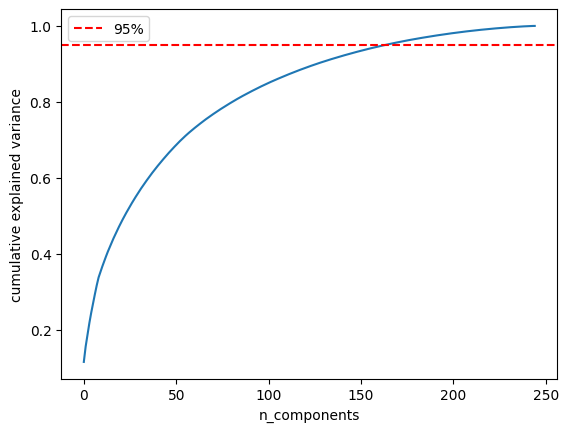

components needed for 95% variance: 165


In [20]:
pca = PCA()
pca.fit(df_pp)
cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.plot(cumvar)
plt.axhline(0.95, color='r', linestyle='--', label='95%')
plt.xlabel("n_components")
plt.ylabel("cumulative explained variance")
plt.legend()
plt.show()

# find the elbow
n = np.argmax(cumvar >= 0.95) + 1
print(f"components needed for 95% variance: {n}")

In [21]:
pca = PCA(n_components=165)
df_pp_pca = pca.fit_transform(df_pp.toarray())
nn_pca = NearestNeighbors(n_neighbors = 10, metric="cosine")
nn_pca.fit(df_pp_pca)
temp_test_pca = pca.transform(temp_test_pp.toarray())

In [22]:
for i in range(0, temp_test_pca.shape[0]):
    print(f"predictions for: {temp_test_names.iloc[i]}")
    print("-------------------------------------")
    distances_pca, indices_pca = nn_pca.kneighbors(temp_test_pca[i].reshape(1, -1))
    for ind, dist in zip(indices_pca[0], distances_pca[0]):
        print(f"{df['channel_name'].iloc[ind]} ({dist:.3f})")
    print("======================================\n")

predictions for: True Crime - Jack!
-------------------------------------
Culture Clash (0.486)
Unlearning (0.640)
ancient mariner  (0.642)
Happen Films (0.699)
EXPLORE WITH US (0.718)
Snook (0.721)
The Northern Philosopher (0.733)
Curious Archive (0.736)
Reflections of Life (0.739)
Kienna Powell: Film and tv  (0.760)

predictions for: Criminal Core
-------------------------------------
Karsten Runquist (0.489)
Schaffrillas Productions (0.585)
The Internet Investigator (0.616)
Wendigoon (0.639)
Sisyphus 55 (0.646)
Horses  (0.670)
exurb1a (0.678)
Quinton Reviews (0.680)
JCS - Criminal Psychology (0.699)
LEMMiNO (0.699)

predictions for: NationSquid
-------------------------------------
Sisyphus 55 (0.423)
Horses  (0.554)
Wendigoon (0.559)
Nexpo (0.559)
Unpredictable (0.575)
Internet Anarchist (0.575)
Jeffiot (0.576)
caitlyn  (0.593)
History Tea Time with Lindsay Holiday (0.598)
Clark Elieson (0.604)

predictions for: James Jani
-------------------------------------
MagnatesMedia (0.370)

In [23]:
df[df["channel_name"] == "hochelaga"]

,channel_id,channel_name,description,topics,keywords,videos
250,UCjP-MiAEn9DPvUHNyGEs7Wg,hochelaga,Biblical lore and more.\n,"Society, Religion, Knowledge","Society, Religion, Knowledge",Survival Guide to Ragnarok | The Norse Apocaly...


In [24]:
df[df["channel_name"] == "Sciencephile the AI"]

,channel_id,channel_name,description,topics,keywords,videos
183,UC7BhHN8NyMMru2RUygnDXSg,Sciencephile the AI,"Smile, life is meaningless.\n",Knowledge,Sciencephile Science Philosophy Astronomy Phys...,When Science Was VERY Wrong Tier List of Extre...


In [25]:
df[df["channel_name"] == "Sciencephile the AI"]["keywords"].values[0]

'Sciencephile Science Philosophy Astronomy Physics Quantum Mechanics'

In [26]:
df[df["channel_name"] == "hochelaga"]["videos"].values[0]

'Survival Guide to Ragnarok | The Norse Apocalypse Explained The Dead Sea Scrolls: The Oldest Biblical Writings Ever Found The Wise Men’s Gifts Explained The REAL Santa Claus was Hardcore The Bones of Santa Claus? A Piece of the True Manger? The Strangest Christian Painting The STRANGEST Christian Relic (The Holy Milk) Christian Relics Explained Dark Christmas Relics'

In [27]:
df[df["channel_name"] == "Sciencephile the AI"]["videos"].values[0]

'When Science Was VERY Wrong Tier List of Extreme Environments The Gradient of Consciousness Explained Rods From God for cavemen in 60 seconds Astronomy misconceptions you might still believe What exactly are "Gray" Holes? The "impossible" material iceberg EXPLAINED The Andromeda Paradox Explained How to go to space WITHOUT rockets Hadean Earth was hell on steroids'

run count vectorizer on just these two examples and look at results?

In [28]:
df_detail = pd.concat([df[df["channel_name"] == "hochelaga"], df[df["channel_name"] == "FilmComicsExplained"]])
df_detail

,channel_id,channel_name,description,topics,keywords,videos
250,UCjP-MiAEn9DPvUHNyGEs7Wg,hochelaga,Biblical lore and more.\n,"Society, Religion, Knowledge","Society, Religion, Knowledge",Survival Guide to Ragnarok | The Norse Apocaly...
51,UCisWUR5UCMcxz_4zT6mI3kA,FilmComicsExplained,"Answering all your questions about Films, Comi...","Video game culture, Film, Entertainment",Film Comics Explained,WE BURY THE DEAD - What Created The Neuro-Zomb...


In [32]:
from sklearn.metrics.pairwise import cosine_similarity
columns = ["description", "topics", "keywords", "videos"]
 
 
# ── Benchmark reference string ────────────────────────────────────────────────
# Printed at the top of the output so you always have the scale in front of you.
BENCHMARKS = """
COSINE SIMILARITY BENCHMARKS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  0.80 – 1.00  ✅  Very High   — Nearly identical content
  0.60 – 0.79  🟡  High        — Strongly related
  0.40 – 0.59  🟠  Moderate    — Some overlap
  0.20 – 0.39  🔴  Low         — Weakly related
  0.00 – 0.19  ⛔  Very Low    — Essentially unrelated
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Note: With only 2 rows the max possible score can be < 1.0
"""
 
 
# ── Four vectorizer configurations ───────────────────────────────────────────
# We store all four vectorizers in a dict so we can loop over them cleanly.
#
#   V1 – CountVectorizer(binary=False)  counts how many times each word appears
#   V2 – CountVectorizer(binary=True)   only records WHETHER a word appears (1/0)
#   V3 – CountVectorizer(ngram_range=(1,2)) also counts two-word phrases ("biblical lore")
#   V4 – TfidfVectorizer                weights words by how rare they are across rows;
#                                        a word that appears in EVERY row gets a low score
vectorizers = {
    "1. CountVectorizer (binary=False)": CountVectorizer(stop_words = "english", binary=False),
    "2. CountVectorizer (binary=True)":  CountVectorizer(stop_words = "english",binary=True),
    "3. CountVectorizer (2-gram)":       CountVectorizer(stop_words = "english",ngram_range=(1, 2)),
    "4. TF-IDF Vectorizer":              TfidfVectorizer(stop_words = "english",),
}
 
print(BENCHMARKS)
 
# all_scores will collect per-column results so we can average them later.
# Structure: { "column_name": [score_v1, score_v2, score_v3, score_v4], ... }
all_scores = {}
 
 
# ── Main loop: one column at a time ──────────────────────────────────────────
for col in columns:
 
    # Print a header showing the raw text for both rows in this column.
    print(f"\n{'═'*60}")
    print(f"  COLUMN: '{col.upper()}'")
    print(f"{'═'*60}")
    print(f"  Row 0: {df_detail[col].iloc[0]}")   # value for hochelaga
    print(f"  Row 1: {df_detail[col].iloc[1]}\n") # value for FilmComicsExplained
 
    col_scores = []  # will hold the 4 similarity scores for this column
 
    # ── Inner loop: one vectorizer at a time ──────────────────────────────────
    for name, vec in vectorizers.items():
 
        # fit_transform does two things at once:
        #   fit   → learns the vocabulary (all unique words/ngrams in this column)
        #   transform → converts each row into a numeric vector of that vocabulary
        # Result: a sparse matrix with shape (2 rows x n_unique_words columns)
        matrix = vec.fit_transform(df_detail[col])
 
        # cosine_similarity returns a 2x2 matrix:
        #   [[sim(row0,row0), sim(row0,row1)],
        #    [sim(row1,row0), sim(row1,row1)]]
        # We want the off-diagonal value [0][1] = similarity between the two channels.
        sim = cosine_similarity(matrix)[0][1]
        col_scores.append(sim)
 
        # Map the numeric score to a human-readable label using the benchmark scale.
        if   sim >= 0.80: label = "✅ Very High"
        elif sim >= 0.60: label = "🟡 High"
        elif sim >= 0.40: label = "🟠 Moderate"
        elif sim >= 0.20: label = "🔴 Low"
        else:             label = "⛔ Very Low"
 
        # Find shared tokens (words/ngrams present in BOTH rows).
        # get_feature_names_out() returns the full vocabulary list.
        feature_names = vec.get_feature_names_out()
 
        # Convert the sparse matrix to a regular numpy array so we can do
        # boolean indexing: arr[0] is the count vector for row 0, arr[1] for row 1.
        arr = matrix.toarray()
 
        # shared_mask is True for every token that has a count > 0 in BOTH rows.
        shared_mask  = (arr[0] > 0) & (arr[1] > 0)
        shared_words = feature_names[shared_mask].tolist()
 
        print(f"  {name}")
        print(f"    Similarity Score : {sim:.4f}  →  {label}")
        print(f"    Shared tokens    : {shared_words if shared_words else 'none'}")
        print()
 
    # Save all 4 scores for this column so we can aggregate them below.
    all_scores[col] = col_scores
 
 
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'═'*60}")
print("  OVERALL SCORES (mean cosine similarity per vectorizer)")
print(f"{'═'*60}")
 
vec_names = list(vectorizers.keys())
 
# Stack all per-column score lists into a 2-D numpy array.
# Shape: (number_of_columns x 4 vectorizers)
score_matrix = np.array(list(all_scores.values()))
 
# Build df_summary: rows = columns analysed, columns = V1...V4 + Mean.
# This gives a quick at-a-glance table of every score.
df_summary = pd.DataFrame(
    score_matrix,
    index=columns,
    columns=[f"V{i+1}" for i in range(len(vec_names))]
)
# Add a Mean column that averages the 4 vectorizer scores for each text column.
df_summary["Mean"] = df_summary.mean(axis=1)
 
print("\nPer-column mean across all 4 vectorizers:")
print(df_summary.round(4).to_string())
 
# Grand mean = single number summarising overall similarity across everything.
print(f"\nGrand mean similarity (all columns, all vectorizers): "
      f"{score_matrix.mean():.4f}")
 
grand = score_matrix.mean()
if   grand >= 0.80: overall = "✅ Very High"
elif grand >= 0.60: overall = "🟡 High"
elif grand >= 0.40: overall = "🟠 Moderate"
elif grand >= 0.20: overall = "🔴 Low"
else:               overall = "⛔ Very Low"
print(f"Overall assessment: {overall}")
 
 
# ── Most frequent words across the whole dataset ──────────────────────────────
print(f"\n{'═'*60}")
print("  MOST FREQUENT WORDS (across all columns, both rows)")
print(f"{'═'*60}")
 
# Concatenate every cell from every column into one big string.
# df_detail[col].str.cat(sep=" ") joins the two row values with a space.
# The outer join then stitches all columns together.
all_text = " ".join(df_detail[col].str.cat(sep=" ") for col in columns)
 
# Fit a fresh CountVectorizer on that single combined string.
# stop_words=None means we keep ALL words including "the", "and", etc.
# Change to stop_words="english" to filter those out.
global_vec  = CountVectorizer(stop_words=None)
global_mat  = global_vec.fit_transform([all_text])  # 1-row matrix
 
# Pair each word with its count and sort highest-first.
word_counts  = dict(zip(global_vec.get_feature_names_out(),
                        global_mat.toarray()[0]))
sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
 
print("\n  Rank  Word                  Count")
print("  ────  ────────────────────  ─────")
for rank, (word, count) in enumerate(sorted_words[:15], 1):
    print(f"  {rank:<5} {word:<22} {count}")


COSINE SIMILARITY BENCHMARKS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  0.80 – 1.00  ✅  Very High   — Nearly identical content
  0.60 – 0.79  🟡  High        — Strongly related
  0.40 – 0.59  🟠  Moderate    — Some overlap
  0.20 – 0.39  🔴  Low         — Weakly related
  0.00 – 0.19  ⛔  Very Low    — Essentially unrelated
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Note: With only 2 rows the max possible score can be < 1.0


════════════════════════════════════════════════════════════
  COLUMN: 'DESCRIPTION'
════════════════════════════════════════════════════════════
  Row 0: Biblical lore and more.

  Row 1: Answering all your questions about Films, Comics and Popular culture in a fun and engaging way!

  1. CountVectorizer (binary=False)
    Similarity Score : 0.0000  →  ⛔ Very Low
    Shared tokens    : none

  2. CountVectorizer (binary=True)
    Similarity Score : 0.0000  →  ⛔ Very Low
    Shared tokens    : none

  3. CountVectorizer (2-gram)
    Similarity Score : 0.0000  →  ⛔ Very Low
 

perhaps clustering would work better

## modeling: one big count vectorizer

In [135]:
df.head()

,channel_id,channel_name,description,topics,keywords,videos
0,UCqgh7QNlVV8kv3LBTJZYWrg,The Film Essay,A video essay channel devoted to making videos...,"Television program, Film, Entertainment",film essay video essay film analysis film revi...,Why Christopher Nolan uses time as architectur...
1,UCjFqcJQXGZ6T6sxyFB-5i6A,Every Frame a Painting,Taylor & Tony are gone again! Thanks for watch...,"Lifestyle (sociology), Entertainment, Film",filmmaking film analysis video essay,Every Frame x Lackadaisy - Interview with Trac...
2,UCr8r7UVsDaRiIQSVUHVBd_A,Nikki Carreon,"Hello!! Just here making silly stuff, making s...","Lifestyle (sociology), Entertainment, Film","Lifestyle (sociology), Entertainment, Film",Why I Went to a MENTAL HOSPITAL. Stranger Thin...
3,UCjKSoJlPgcK6BmoSqXpj5xQ,Action Button,patreon.com/actionbutton\ntwitch.tv/actionbutt...,"Role-playing video game, Action-adventure game...","Role-playing video game, Action-adventure game...","ACTION BUTTON PICTURES PRESENTS ""LOS ANGELES N..."
4,UCUyvQV2JsICeLZP4c_h40kA,Thomas Flight,"Exploring the artistry behind cinema, TV, and ...","Entertainment, Film, Lifestyle (sociology)",movies film video essays film essay,Why Some Movies Feel More Alive Top 10 Films o...


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   channel_id    251 non-null    object
 1   channel_name  251 non-null    object
 2   description   251 non-null    object
 3   topics        251 non-null    object
 4   keywords      251 non-null    object
 5   videos        251 non-null    object
dtypes: object(6)
memory usage: 11.9+ KB


In [137]:
df["text"] = df["description"] + "\n" + df["topics"] + "\n" + df["keywords"]  + "\n" + df["videos"]

In [138]:
df = df.drop(["description", "topics", "keywords", "videos"], axis=1)

In [139]:
df.head()

,channel_id,channel_name,text
0,UCqgh7QNlVV8kv3LBTJZYWrg,The Film Essay,A video essay channel devoted to making videos...
1,UCjFqcJQXGZ6T6sxyFB-5i6A,Every Frame a Painting,Taylor & Tony are gone again! Thanks for watch...
2,UCr8r7UVsDaRiIQSVUHVBd_A,Nikki Carreon,"Hello!! Just here making silly stuff, making s..."
3,UCjKSoJlPgcK6BmoSqXpj5xQ,Action Button,patreon.com/actionbutton\ntwitch.tv/actionbutt...
4,UCUyvQV2JsICeLZP4c_h40kA,Thomas Flight,"Exploring the artistry behind cinema, TV, and ..."


In [140]:
print(df.head().iloc[0]["text"])

A video essay channel devoted to making videos exploring cinema as a medium, the techniques used and all that lies beyond.
Like me on Facebook!    https://www.facebook.com/Thefilmessay/?ref=aymt_homepage_panel

For all business-related enquires: thefilmessay@gmail.com

Television program, Film, Entertainment
film essay video essay film analysis film review cinema analysis film theory every frame a painting
Why Christopher Nolan uses time as architecture Where did Stranger Things go wrong? Movie Recommendations: 10 hidden gems you haven't seen Paddington 2 is a Cinematic Masterpiece The Musical Storytelling of Succession MODERN NEO-NOIR: From Taxi Driver (1976) to Flinch (2021) Eric Andre's Anti Talk-Show A weeks work for 30 seconds of film... #shorts OSCAR NOMINATION REACTION ANOTHER ROUND (Thomas Vinterberg nominated for Best Director) #shorts Why The Sound of Metal should Win an Oscar - Analysis


In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   channel_id    251 non-null    object
 1   channel_name  251 non-null    object
 2   text          251 non-null    object
dtypes: object(3)
memory usage: 6.0+ KB


In [ ]:
ct = make_column_transformer(
    (CountVectorizer(stop_words="english", max_features=200, min_df=2, max_df = 0.95), "text"), #TODO: figure out best hyperparameters
    ("drop", ["channel_id", "channel_name"]),
)
df_big = ct.fit_transform(df[:-5])
nn_big = NearestNeighbors(n_neighbors=10, metric="cosine")
nn_big.fit(df_big)